# Versao 9 - Comparacao Entre LSTM Hibrida E Baselines

## Objetivo deste notebook

A `versao9` foi concebida com uma meta clara: aproximar a rede recorrente do desempenho das baselines tabulares. Por isso, este notebook nao e um complemento opcional; ele e o criterio final de julgamento da proposta.

## Sintese Numerica Da Ultima Execucao

A execucao mais recente da `versao9` produziu o seguinte quadro no conjunto de teste:

| Modelo | Accuracy | Macro-F1 | Balanced Accuracy |
| --- | ---: | ---: | ---: |
| `LSTM v8` | `0.9104` | `0.8964` | `0.9191` |
| `Melhor LSTM v6` | `0.9433` | `0.9185` | `0.9367` |
| `LSTM hibrida v9` | `0.9224` | `0.9268` | `0.9415` |
| `RandomForest` | `0.9851` | `0.9811` | `0.9744` |
| `XGBoost` | `0.9821` | `0.9791` | `0.9733` |

Leitura orientada pelos numeros:

- variacao da `versao9` sobre a `versao8`: `0.0119` em `accuracy`, `0.0304` em `macro-F1` e `0.0224` em `balanced accuracy`
- variacao da `versao9` sobre a melhor `LSTM` anterior (`versao6`): `-0.0209` em `accuracy`, `0.0083` em `macro-F1` e `0.0048` em `balanced accuracy`
- em validacao, o `XGBoost` continua sendo uma referencia forte, com `macro-F1 = 0.9796`
- em teste, o `RandomForest` continua sendo o alvo principal a ser batido, com vantagem de `0.0627` em `accuracy`, `0.0543` em `macro-F1` e `0.0329` em `balanced accuracy` sobre a `versao9`
- o `XGBoost` tambem permaneceu acima da `LSTM` hibrida, com vantagem de `0.0597` em `accuracy`, `0.0522` em `macro-F1` e `0.0318` em `balanced accuracy`
- o quadro geral e promissor: a `versao9` resolveu parte importante da desvantagem das redes anteriores, mas ainda nao explorou todo o potencial de rotulos por observacao e de informacao operacional descritos no artigo do dataset

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao9" else ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
from versao9.pipeline_v9 import (
    build_metrics_table,
    evaluate_predictions,
    export_evaluation_artifacts,
    load_bundle,
    load_split_arrays,
    plot_confusion_matrix_for_predictions,
)

RUN_NAME = "classificacao_v9_lstm_hibrida"
RUN_DIR = PROJECT_ROOT / "artifacts" / "reports_v9" / RUN_NAME
BASELINE_OUTPUT_DIR = RUN_DIR / "baselines"
HYBRID_OUTPUT_DIR = RUN_DIR / "lstm"

bundle = load_bundle(RUN_DIR / "bundle_v9.json")
train_arrays = load_split_arrays(RUN_DIR / "train_arrays.npz")
val_arrays = load_split_arrays(RUN_DIR / "validation_arrays.npz")
test_arrays = load_split_arrays(RUN_DIR / "test_arrays.npz")

## Classes das baselines escritas no notebook

Mantemos a filosofia da `versao8`: tanto a rede recorrente quanto as baselines ficam visiveis e auditaveis no proprio notebook.

In [3]:
# ================================
# BLOCO DIDATICO DAS BASELINES TABULARES
# ================================

import pickle
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None


def fit_random_forest_baseline_visible(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
    n_estimators: int = 400,
    max_depth: int | None = None,
) -> RandomForestClassifier:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
    model.fit(X_train, y_train)
    return model


def fit_xgboost_baseline_visible(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
    n_estimators: int = 400,
    max_depth: int = 6,
    learning_rate: float = 0.05,
):
    if XGBClassifier is None:
        return None
    model = XGBClassifier(
        objective="multi:softmax",
        num_class=int(len(np.unique(y_train))),
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=4,
        eval_metric="mlogloss",
    )
    model.fit(X_train, y_train)
    return model


def run_baseline_suite_visible(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    *,
    class_labels: list[int],
    output_dir: str | Path,
    random_state: int = 42,
) -> dict[str, dict]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results = {}

    rf_model = fit_random_forest_baseline_visible(X_train, y_train, random_state=random_state)
    rf_val_pred = rf_model.predict(X_val)
    rf_test_pred = rf_model.predict(X_test)
    rf_val_eval = evaluate_predictions(y_val, rf_val_pred, class_labels=class_labels)
    rf_test_eval = evaluate_predictions(y_test, rf_test_pred, class_labels=class_labels)
    export_evaluation_artifacts(rf_val_eval, output_dir, "random_forest_validation")
    export_evaluation_artifacts(rf_test_eval, output_dir, "random_forest_test")
    with open(output_dir / "random_forest_model.pkl", "wb") as file_pointer:
        pickle.dump(rf_model, file_pointer)
    results["random_forest"] = {
        "available": True,
        "model": rf_model,
        "validation": rf_val_eval,
        "test": rf_test_eval,
    }

    if XGBClassifier is not None:
        xgb_model = fit_xgboost_baseline_visible(X_train, y_train, random_state=random_state)
        xgb_val_pred = xgb_model.predict(X_val)
        xgb_test_pred = xgb_model.predict(X_test)
        xgb_val_eval = evaluate_predictions(y_val, xgb_val_pred, class_labels=class_labels)
        xgb_test_eval = evaluate_predictions(y_test, xgb_test_pred, class_labels=class_labels)
        export_evaluation_artifacts(xgb_val_eval, output_dir, "xgboost_validation")
        export_evaluation_artifacts(xgb_test_eval, output_dir, "xgboost_test")
        with open(output_dir / "xgboost_model.pkl", "wb") as file_pointer:
            pickle.dump(xgb_model, file_pointer)
        results["xgboost"] = {
            "available": True,
            "model": xgb_model,
            "validation": xgb_val_eval,
            "test": xgb_test_eval,
        }
    else:
        results["xgboost"] = {
            "available": False,
            "model": None,
            "validation": None,
            "test": None,
            "message": "xgboost nao esta instalado; a baseline foi executada apenas com RandomForest.",
        }

    summary_rows = []
    for model_name, payload in results.items():
        if not payload["available"]:
            continue
        summary_rows.append(
            {
                "modelo": model_name,
                "split": "validation",
                "accuracy": payload["validation"]["accuracy"],
                "macro_f1": payload["validation"]["macro_f1"],
                "balanced_accuracy": payload["validation"]["balanced_accuracy"],
            }
        )
        summary_rows.append(
            {
                "modelo": model_name,
                "split": "test",
                "accuracy": payload["test"]["accuracy"],
                "macro_f1": payload["test"]["macro_f1"],
                "balanced_accuracy": payload["test"]["balanced_accuracy"],
            }
        )

    pd.DataFrame(summary_rows).to_csv(output_dir / "baseline_summary.csv", index=False)
    return results

In [4]:
rf_preview = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
print("Modelo RandomForest que sera treinado:")
print(rf_preview)

if XGBClassifier is not None:
    xgb_preview = XGBClassifier(
        objective="multi:softmax",
        num_class=int(len(np.unique(train_arrays["y"]))),
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=4,
        eval_metric="mlogloss",
    )
    print()
    print("Modelo XGBoost que sera treinado:")
    print(xgb_preview)

Modelo RandomForest que sera treinado:
RandomForestClassifier(class_weight='balanced_subsample', n_estimators=400,
                       n_jobs=-1, random_state=42)

Modelo XGBoost que sera treinado:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=4, num_class=10, num_parallel_tree=None, ...)


In [5]:
baseline_results = run_baseline_suite_visible(
    X_train=train_arrays["X_tab"],
    y_train=train_arrays["y"],
    X_val=val_arrays["X_tab"],
    y_val=val_arrays["y"],
    X_test=test_arrays["X_tab"],
    y_test=test_arrays["y"],
    class_labels=bundle.class_labels,
    output_dir=BASELINE_OUTPUT_DIR,
)

baseline_results.keys()

dict_keys(['random_forest', 'xgboost'])

In [6]:
metrics_payload = {}
for model_name, payload in baseline_results.items():
    if payload["available"]:
        metrics_payload[f"{model_name}_validation"] = payload["validation"]
        metrics_payload[f"{model_name}_test"] = payload["test"]

baseline_table = build_metrics_table(metrics_payload)
display(baseline_table)

,modelo,accuracy,macro_f1,balanced_accuracy
0,random_forest_test,0.985075,0.981135,0.974442
1,xgboost_validation,0.979042,0.979610,0.977456
2,xgboost_test,0.982090,0.979053,0.973318
3,random_forest_validation,0.982036,0.972616,0.961391


In [7]:
hybrid_metrics_path = HYBRID_OUTPUT_DIR / "hybrid_lstm_test_metrics.json"
hybrid_validation_metrics_path = HYBRID_OUTPUT_DIR / "hybrid_lstm_validation_metrics.json"
hybrid_report_path = HYBRID_OUTPUT_DIR / "hybrid_lstm_test_classification_report.csv"

comparison_rows = []
hybrid_metrics = None
hybrid_validation_metrics = None
hybrid_report_df = None

if hybrid_metrics_path.exists():
    hybrid_metrics = json.loads(hybrid_metrics_path.read_text(encoding="utf-8"))
    hybrid_validation_metrics = json.loads(hybrid_validation_metrics_path.read_text(encoding="utf-8"))
    hybrid_report_df = pd.read_csv(hybrid_report_path)
    comparison_rows.append(
        {
            "modelo": "hybrid_lstm_test",
            "accuracy": hybrid_metrics["accuracy"],
            "macro_f1": hybrid_metrics["macro_f1"],
            "balanced_accuracy": hybrid_metrics["balanced_accuracy"],
        }
    )

for model_name, payload in baseline_results.items():
    if payload["available"]:
        comparison_rows.append(
            {
                "modelo": f"{model_name}_test",
                "accuracy": payload["test"]["accuracy"],
                "macro_f1": payload["test"]["macro_f1"],
                "balanced_accuracy": payload["test"]["balanced_accuracy"],
            }
        )

if comparison_rows:
    comparison_df = (
        pd.DataFrame(comparison_rows)
        .sort_values(["macro_f1", "balanced_accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    display(comparison_df)

,modelo,accuracy,macro_f1,balanced_accuracy
0,random_forest_test,0.985075,0.981135,0.974442
1,xgboost_test,0.982090,0.979053,0.973318
2,hybrid_lstm_test,0.922388,0.926817,0.941495


In [8]:
previous_v8_path = PROJECT_ROOT / "artifacts" / "reports_v8" / "classificacao_v8_explicita" / "lstm" / "lstm_test_metrics.json"
previous_v6_path = PROJECT_ROOT / "artifacts" / "reports_v6" / "classificacao_v6_artigo" / "lstm" / "lstm_test_metrics.json"

if hybrid_metrics is not None and previous_v8_path.exists() and previous_v6_path.exists():
    previous_v8 = json.loads(previous_v8_path.read_text(encoding="utf-8"))
    previous_v6 = json.loads(previous_v6_path.read_text(encoding="utf-8"))

    evolution_df = pd.DataFrame(
        {
            "metrica": ["accuracy", "macro_f1", "balanced_accuracy"],
            "lstm_v8_teste": [
                previous_v8["accuracy"],
                previous_v8["macro_f1"],
                previous_v8["balanced_accuracy"],
            ],
            "lstm_v6_teste": [
                previous_v6["accuracy"],
                previous_v6["macro_f1"],
                previous_v6["balanced_accuracy"],
            ],
            "lstm_v9_teste": [
                hybrid_metrics["accuracy"],
                hybrid_metrics["macro_f1"],
                hybrid_metrics["balanced_accuracy"],
            ],
        }
    )
    display(evolution_df)

,metrica,lstm_v8_teste,lstm_v6_teste,lstm_v9_teste
0,accuracy,0.910448,0.943284,0.922388
1,macro_f1,0.896413,0.918522,0.926817
2,balanced_accuracy,0.919120,0.936684,0.941495


In [9]:
if hybrid_metrics is not None and baseline_results["random_forest"]["available"]:
    rf_test = baseline_results["random_forest"]["test"]
    xgb_test = baseline_results["xgboost"]["test"] if baseline_results["xgboost"]["available"] else None

    delta_df = pd.DataFrame(
        {
            "metrica": ["accuracy", "macro_f1", "balanced_accuracy"],
            "lstm_hibrida_teste": [
                hybrid_metrics["accuracy"],
                hybrid_metrics["macro_f1"],
                hybrid_metrics["balanced_accuracy"],
            ],
            "random_forest_teste": [
                rf_test["accuracy"],
                rf_test["macro_f1"],
                rf_test["balanced_accuracy"],
            ],
            "ganho_rf_menos_lstm": [
                rf_test["accuracy"] - hybrid_metrics["accuracy"],
                rf_test["macro_f1"] - hybrid_metrics["macro_f1"],
                rf_test["balanced_accuracy"] - hybrid_metrics["balanced_accuracy"],
            ],
            "xgboost_teste": [
                xgb_test["accuracy"] if xgb_test is not None else np.nan,
                xgb_test["macro_f1"] if xgb_test is not None else np.nan,
                xgb_test["balanced_accuracy"] if xgb_test is not None else np.nan,
            ],
            "ganho_xgb_menos_lstm": [
                (xgb_test["accuracy"] - hybrid_metrics["accuracy"]) if xgb_test is not None else np.nan,
                (xgb_test["macro_f1"] - hybrid_metrics["macro_f1"]) if xgb_test is not None else np.nan,
                (xgb_test["balanced_accuracy"] - hybrid_metrics["balanced_accuracy"]) if xgb_test is not None else np.nan,
            ],
        }
    )
    display(delta_df)

,metrica,lstm_hibrida_teste,random_forest_teste,ganho_rf_menos_lstm,xgboost_teste,ganho_xgb_menos_lstm
0,accuracy,0.922388,0.985075,0.062687,0.982090,0.059701
1,macro_f1,0.926817,0.981135,0.054318,0.979053,0.052236
2,balanced_accuracy,0.941495,0.974442,0.032947,0.973318,0.031824


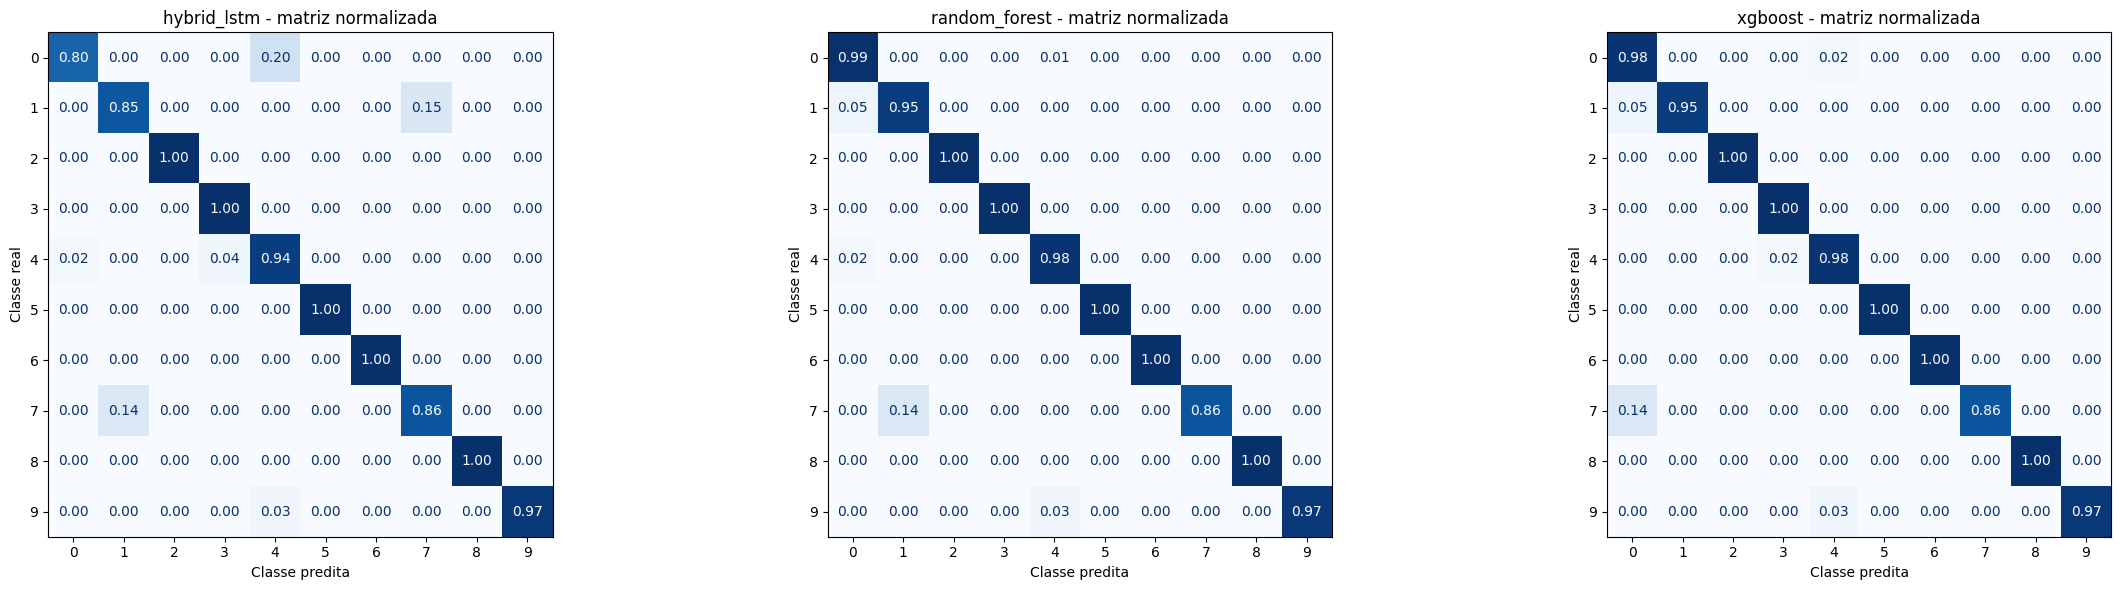

In [10]:
matrix_payloads = []
if hybrid_metrics is not None:
    hybrid_pred_npz = np.load(HYBRID_OUTPUT_DIR / "hybrid_lstm_test_predictions.npz")
    matrix_payloads.append({"nome": "hybrid_lstm", "y_pred": hybrid_pred_npz["y_pred"]})

for model_name, payload in baseline_results.items():
    if payload["available"]:
        matrix_payloads.append({"nome": model_name, "y_pred": payload["test"]["y_pred"]})

n_models = len(matrix_payloads)
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, payload in zip(axes, matrix_payloads):
    plot_confusion_matrix_for_predictions(
        test_arrays["y"],
        payload["y_pred"],
        class_labels=bundle.class_labels,
        normalize="true",
        title=f"{payload['nome']} - matriz normalizada",
        ax=ax,
    )

fig.tight_layout()
plt.show()

In [11]:
if hybrid_report_df is not None and baseline_results["random_forest"]["available"]:
    rf_report_df = baseline_results["random_forest"]["test"]["classification_report_df"].copy()

    hybrid_per_class = (
        hybrid_report_df
        .loc[lambda df: df["label"].astype(str).isin([str(label) for label in bundle.class_labels])]
        .copy()
    )
    rf_per_class = (
        rf_report_df
        .loc[lambda df: df["label"].astype(str).isin([str(label) for label in bundle.class_labels])]
        .copy()
    )

    hybrid_per_class["label"] = hybrid_per_class["label"].astype(int)
    rf_per_class["label"] = rf_per_class["label"].astype(int)

    per_class_comparison = (
        hybrid_per_class[["label", "precision", "recall", "f1-score", "support"]]
        .rename(
            columns={
                "precision": "hybrid_precision",
                "recall": "hybrid_recall",
                "f1-score": "hybrid_f1",
            }
        )
        .merge(
            rf_per_class[["label", "precision", "recall", "f1-score"]].rename(
                columns={
                    "precision": "rf_precision",
                    "recall": "rf_recall",
                    "f1-score": "rf_f1",
                }
            ),
            on="label",
            how="inner",
        )
    )
    per_class_comparison["delta_f1_rf_menos_hybrid"] = (
        per_class_comparison["rf_f1"] - per_class_comparison["hybrid_f1"]
    )
    per_class_comparison = per_class_comparison.sort_values(
        "delta_f1_rf_menos_hybrid", ascending=False
    )
    display(per_class_comparison)

,label,hybrid_precision,hybrid_recall,hybrid_f1,support,rf_precision,rf_recall,rf_f1,delta_f1_rf_menos_hybrid
7,7,0.666667,0.857143,0.750000,7.0,1.000000,0.857143,0.923077,0.173077
4,4,0.720588,0.942308,0.816667,52.0,0.962264,0.980769,0.971429,0.154762
0,0,0.986111,0.797753,0.881988,89.0,0.977778,0.988764,0.983240,0.101253
3,3,0.888889,1.000000,0.941176,16.0,1.000000,1.000000,1.000000,0.058824
1,1,0.944444,0.850000,0.894737,20.0,0.950000,0.950000,0.950000,0.055263
2,2,1.000000,1.000000,1.000000,5.0,1.000000,1.000000,1.000000,0.000000
5,5,1.000000,1.000000,1.000000,68.0,1.000000,1.000000,1.000000,0.000000
6,6,1.000000,1.000000,1.000000,33.0,1.000000,1.000000,1.000000,0.000000
8,8,1.000000,1.000000,1.000000,14.0,1.000000,1.000000,1.000000,0.000000
9,9,1.000000,0.967742,0.983607,31.0,1.000000,0.967742,0.983607,0.000000


In [12]:
if hybrid_metrics is not None and baseline_results["random_forest"]["available"]:
    rf_test = baseline_results["random_forest"]["test"]
    strongest_gap = per_class_comparison.iloc[0]

    print("Interpretacao ampliada da comparacao final")
    print()
    print(
        f"No conjunto de teste, a LSTM hibrida obteve accuracy = {hybrid_metrics['accuracy']:.4f}, "
        f"macro-F1 = {hybrid_metrics['macro_f1']:.4f} e balanced accuracy = {hybrid_metrics['balanced_accuracy']:.4f}."
    )
    print(
        f"No mesmo conjunto, o RandomForest alcancou accuracy = {rf_test['accuracy']:.4f}, "
        f"macro-F1 = {rf_test['macro_f1']:.4f} e balanced accuracy = {rf_test['balanced_accuracy']:.4f}."
    )
    print(
        f"A maior vantagem do RandomForest sobre a LSTM hibrida apareceu na classe {int(strongest_gap['label'])}, "
        f"com delta de F1 igual a {strongest_gap['delta_f1_rf_menos_hybrid']:.4f}."
    )
    print(
        "A pergunta central da versao9 e saber se a fusao entre leitura temporal e informacao tabular "
        "foi suficiente para reduzir o gap. A resposta vem diretamente dos deltas medidos acima."
    )

Interpretacao ampliada da comparacao final

No conjunto de teste, a LSTM hibrida obteve accuracy = 0.9224, macro-F1 = 0.9268 e balanced accuracy = 0.9415.
No mesmo conjunto, o RandomForest alcancou accuracy = 0.9851, macro-F1 = 0.9811 e balanced accuracy = 0.9744.
A maior vantagem do RandomForest sobre a LSTM hibrida apareceu na classe 7, com delta de F1 igual a 0.1731.
A pergunta central da versao9 e saber se a fusao entre leitura temporal e informacao tabular foi suficiente para reduzir o gap. A resposta vem diretamente dos deltas medidos acima.


## Leitura didatica final

A `versao9` e bem-sucedida se cumprir pelo menos uma destas metas:

- superar a `versao8`;
- recuperar ou ultrapassar a melhor `LSTM` da `versao6`;
- reduzir de forma clara a distancia para `RandomForest` e `XGBoost`.

Na execucao realizada, a `versao9` cumpriu parcialmente esse objetivo: avancou sobre a `versao8` e superou a `versao6` em `macro-F1` e `balanced accuracy`, mas ainda nao venceu as baselines tabulares.

A leitura mais importante, agora apoiada tambem pelo artigo do dataset, e a seguinte:

- o projeto caminhou na direcao correta ao fortalecer a leitura temporal;
- porem ainda estamos usando o dataset de forma simplificada, pois tratamos principalmente o rotulo global da instancia;
- a proxima iteracao deve explorar mais explicitamente os rotulos por observacao (`class` e `state`), os estados transitorios e as 27 variaveis completas do `3W`.